# FASE 6D: Modelo Jerárquico Optimizado (Anti-Overfitting)

**Objetivo:** Implementar el modelo jerárquico evitando el overfitting y reduciendo los falsos positivos/negativos. Para esto usaremos:
1. **Hiperparámetros Regularizados:** Los mejores hiperparámetros encontrados en la Fase 6B (subsample, colsample, reg_alpha, reg_lambda) que evitan el sobreajuste.
2. **Threshold Tuning con Validación Cruzada:** En vez de usar el corte de 0.5 por defecto para el Modelo 1, buscaremos el umbral óptimo usando CV (K-Fold) para maximizar el F1-Score sin espiar los datos de prueba.

In [1]:
%load_ext kedro.ipython

[06/16/26 16:15:49] INFO     Using                                                                  ]8;id=509239;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=173161;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packa                
                             ges\kedro\framework\project\rich_logging.yml' as logging                              
                             configuration.                                                                        

[06/16/26 16:15:50] INFO     Registered line magic '%reload_kedro'                                   ]8;id=463902;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=62180;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=932544;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=942102;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=140661;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=284628;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\alarc\OneDrive\Escritorio\Proyecto_Nhanes_Kedro\proyecto_nhan                
                             es_kedro.                                                                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/16/26 16:15:52] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=490137;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=586294;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project Proyecto NHANES Kedro                                    ]8;id=905882;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=710065;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

[06/16/26 16:15:53] INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=574857;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=449496;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
TARGET_COL = 'DIABETES_RISK'

In [3]:
# 1. Carga de Datos
df = catalog.load('df_master')

exclude_cols = ['SEQN', TARGET_COL]
feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

def build_preprocessor(num_cols, cat_cols):
    num_tf = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    tfs = [('num', num_tf, num_cols)]
    if cat_cols:
        cat_tf = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                           ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
        tfs.append(('cat', cat_tf, cat_cols))
    return ColumnTransformer(transformers=tfs, remainder='drop')

print("Datos cargados correctamente.")

[06/16/26 16:16:24] INFO     Loading data from df_master (ParquetDataset)...                   ]8;id=343400;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=415112;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

Datos cargados correctamente.


---
## 2. Entrenamiento del Modelo 1 (Diabetes vs No Diabetes) con Anti-Overfitting

In [4]:
y_train_m1 = (y_train == 2).astype(int)
y_test_m1 = (y_test == 2).astype(int)

print("Distribución Modelo 1 (Train):")
print(y_train_m1.value_counts(normalize=True))

# Usamos parámetros fuertemente regularizados para evitar memorizar datos (overfitting)
model1_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(numeric_cols, categorical_cols)),
    ('classifier', XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        n_estimators=700, max_depth=5, learning_rate=0.01,
        min_child_weight=1, subsample=0.9, colsample_bytree=0.5,
        gamma=0.5, reg_alpha=0.01, reg_lambda=3.0,
        scale_pos_weight=(len(y_train_m1) - y_train_m1.sum()) / y_train_m1.sum(),
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

print("\nBuscando el umbral óptimo (Threshold Tuning) con Validación Cruzada (CV=5)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_proba_cv_m1 = cross_val_predict(model1_pipeline, X_train, y_train_m1, cv=cv, method='predict_proba')[:, 1]

thresholds = np.linspace(0.3, 0.8, 51)
f1_scores = [f1_score(y_train_m1, (y_proba_cv_m1 >= t).astype(int)) for t in thresholds]
best_th_m1 = thresholds[np.argmax(f1_scores)]

print(f"Mejor Threshold para Modelo 1: {best_th_m1:.3f} (Maximizando F1 sin tocar el Test set)")

# Entrenamos con todos los datos de Train ahora
model1_pipeline.fit(X_train, y_train_m1)

# Evaluación Modelo 1 en Test
y_proba_test_m1 = model1_pipeline.predict_proba(X_test)[:, 1]
y_pred_m1 = (y_proba_test_m1 >= best_th_m1).astype(int)

print("\n=== EVALUACIÓN MODELO 1 OPTIMIZADO: Diabetes vs No Diabetes ===")
print(classification_report(y_test_m1, y_pred_m1, target_names=['No Diabetes', 'Diabetes']))

Distribución Modelo 1 (Train):
DIABETES_RISK
0    0.875724
1    0.124276
Name: proportion, dtype: float64

Buscando el umbral óptimo (Threshold Tuning) con Validación Cruzada (CV=5)...
Mejor Threshold para Modelo 1: 0.540 (Maximizando F1 sin tocar el Test set)

=== EVALUACIÓN MODELO 1 OPTIMIZADO: Diabetes vs No Diabetes ===
              precision    recall  f1-score   support

 No Diabetes       0.96      0.95      0.96      1059
    Diabetes       0.68      0.75      0.72       150

    accuracy                           0.93      1209
   macro avg       0.82      0.85      0.84      1209
weighted avg       0.93      0.93      0.93      1209



---
## 3. Entrenamiento del Modelo 2 (Riesgo de Prediabetes) con Anti-Overfitting

In [5]:
# Filtramos pacientes sin diabetes original
mask_train = y_train < 2
X_train_m2 = X_train[mask_train]
y_train_m2 = y_train[mask_train] # 0: Sano, 1: Prediabetes

mask_test = y_test < 2
X_test_m2 = X_test[mask_test]
y_test_m2 = y_test[mask_test]

# Misma estrategia de regularización
model2_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(numeric_cols, categorical_cols)),
    ('classifier', XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        n_estimators=700, max_depth=5, learning_rate=0.01,
        min_child_weight=1, subsample=0.9, colsample_bytree=0.5,
        gamma=0.5, reg_alpha=0.01, reg_lambda=3.0,
        scale_pos_weight=(len(y_train_m2) - y_train_m2.sum()) / y_train_m2.sum(),
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

model2_pipeline.fit(X_train_m2, y_train_m2)

# Evaluación Modelo 2
y_pred_m2 = model2_pipeline.predict(X_test_m2)
print("\n=== EVALUACIÓN MODELO 2 OPTIMIZADO: Sano vs Prediabetes ===")
print(classification_report(y_test_m2, y_pred_m2, target_names=['Sano', 'Prediabetes']))


=== EVALUACIÓN MODELO 2 OPTIMIZADO: Sano vs Prediabetes ===
              precision    recall  f1-score   support

        Sano       0.89      0.77      0.83       732
 Prediabetes       0.61      0.78      0.68       327

    accuracy                           0.78      1059
   macro avg       0.75      0.78      0.76      1059
weighted avg       0.80      0.78      0.78      1059



---
## 4. Flujo Clínico Ensamblado y Resultados Finales

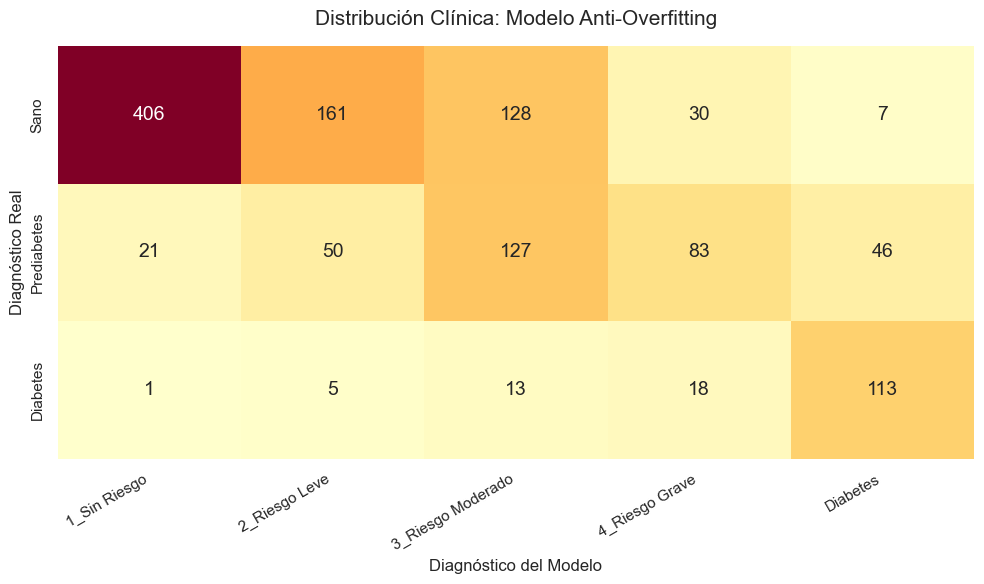

ANÁLISIS PORCENTUAL FINAL

Pacientes que realmente son: SANO (Total: 732)
  -> Clasificados como 1_Sin Riesgo.............  55.5% (406 pac.)
  -> Clasificados como 2_Riesgo Leve............  22.0% (161 pac.)
  -> Clasificados como 3_Riesgo Moderado........  17.5% (128 pac.)
  -> Clasificados como 4_Riesgo Grave...........   4.1% (30 pac.)
  -> Clasificados como Diabetes.................   1.0% (7 pac.)

Pacientes que realmente son: PREDIABETES (Total: 327)
  -> Clasificados como 1_Sin Riesgo.............   6.4% (21 pac.)
  -> Clasificados como 2_Riesgo Leve............  15.3% (50 pac.)
  -> Clasificados como 3_Riesgo Moderado........  38.8% (127 pac.)
  -> Clasificados como 4_Riesgo Grave...........  25.4% (83 pac.)
  -> Clasificados como Diabetes.................  14.1% (46 pac.)

Pacientes que realmente son: DIABETES (Total: 150)
  -> Clasificados como 1_Sin Riesgo.............   0.7% (1 pac.)
  -> Clasificados como 2_Riesgo Leve............   3.3% (5 pac.)
  -> Clasificados como 3_R

In [6]:
def clinical_prediction_flow(X):
    # 1. Prediccion Modelo 1 con el Threshold optimizado
    prob_diabetes = model1_pipeline.predict_proba(X)[:, 1]
    is_diabetes = (prob_diabetes >= best_th_m1).astype(int)
    
    # 2. Probabilidad de Prediabetes Modelo 2
    prob_prediabetes = model2_pipeline.predict_proba(X)[:, 1]
    
    # 3. Mapeo a escalas de riesgo
    categories = []
    for diabetes_flag, prob in zip(is_diabetes, prob_prediabetes):
        if diabetes_flag == 1:
            categories.append('Diabetes')
        else:
            if prob < 0.25:
                categories.append('1_Sin Riesgo')
            elif prob < 0.50:
                categories.append('2_Riesgo Leve')
            elif prob < 0.75:
                categories.append('3_Riesgo Moderado')
            else:
                categories.append('4_Riesgo Grave')
                
    return categories

final_predictions = clinical_prediction_flow(X_test)

df_results = pd.DataFrame({
    'Clase Real': y_test.map({0: 'Sano', 1: 'Prediabetes', 2: 'Diabetes'}),
    'Clasificación Clínica': final_predictions
})

crosstab = pd.crosstab(df_results['Clase Real'], df_results['Clasificación Clínica'])
ordered_cols = ['1_Sin Riesgo', '2_Riesgo Leve', '3_Riesgo Moderado', '4_Riesgo Grave', 'Diabetes']
ordered_rows = ['Sano', 'Prediabetes', 'Diabetes']
crosstab = crosstab.reindex(index=ordered_rows, columns=ordered_cols, fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar=False, annot_kws={"size": 14})
plt.title('Distribución Clínica: Modelo Anti-Overfitting', fontsize=15, pad=15)
plt.ylabel('Diagnóstico Real', fontsize=12)
plt.xlabel('Diagnóstico del Modelo', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("="*65)
print("ANÁLISIS PORCENTUAL FINAL")
print("="*65)
for index, row in crosstab.iterrows():
    total = row.sum()
    print(f"\nPacientes que realmente son: {index.upper()} (Total: {total})")
    for col in ordered_cols:
        pct = (row[col] / total) * 100
        if pct > 0:
            print(f"  -> Clasificados como {col:.<25} {pct:>5.1f}% ({row[col]} pac.)")


---
## 5. Simulación de API en Producción

Vamos a simular un entorno de producción donde una API recibe los datos clínicos de un paciente en formato JSON (payload) y utiliza los modelos entrenados en memoria para devolver un diagnóstico en tiempo real.

In [7]:
import json

def api_predict_risk(patient_json, model1, model2, threshold_m1):
    """Simula un endpoint de API que recibe un JSON y retorna el diagnóstico"""
    # 1. Parsear el JSON a Diccionario y luego a DataFrame
    patient_dict = json.loads(patient_json)
    df_patient = pd.DataFrame([patient_dict])
    
    # 2. Pipeline Modelo 1 (Diabetes vs No Diabetes)
    prob_diabetes = model1.predict_proba(df_patient)[:, 1][0]
    
    # 3. Lógica de Decisión Jerárquica
    if prob_diabetes >= threshold_m1:
        diagnostico = 'Diabetes'
        probabilidad = prob_diabetes
    else:
        # 4. Pipeline Modelo 2 (Prediabetes en Sanos)
        prob_prediabetes = model2.predict_proba(df_patient)[:, 1][0]
        probabilidad = prob_prediabetes
        
        if prob_prediabetes < 0.25:
            diagnostico = '1_Sin Riesgo'
        elif prob_prediabetes < 0.50:
            diagnostico = '2_Riesgo Leve'
        elif prob_prediabetes < 0.75:
            diagnostico = '3_Riesgo Moderado'
        else:
            diagnostico = '4_Riesgo Grave'
            
    return {
        'diagnostico': diagnostico,
        'probabilidad': float(probabilidad)
    }

# Seleccionamos 5 pacientes distintos del conjunto de prueba (X_test)
# Para la prueba, tomaremos 2 sanos, 2 prediabéticos y 1 diabético real
np.random.seed(42)
sanos_idx = y_test[y_test == 0].sample(2).index
prediab_idx = y_test[y_test == 1].sample(2).index
diab_idx = y_test[y_test == 2].sample(1).index

pacientes_prueba = X_test.loc[sanos_idx.union(prediab_idx).union(diab_idx)]
etiquetas_reales = y_test.loc[pacientes_prueba.index]
map_real = {0: 'Sano', 1: 'Prediabetes', 2: 'Diabetes'}

print("=== INICIANDO SIMULACIÓN DE API PARA 5 PACIENTES ===\n")

for i, (idx, row) in enumerate(pacientes_prueba.iterrows(), 1):
    # Simulamos el envío del payload convirtiendo la fila a JSON
    payload_json = row.to_json()
    
    # Llamamos a la "API"
    respuesta_api = api_predict_risk(payload_json, model1_pipeline, model2_pipeline, best_th_m1)
    
    verdad_real = map_real[etiquetas_reales.loc[idx]]
    
    print(f"🏥 PACIENTE {i}")
    print(f"   Estado Real del Paciente : {verdad_real}")
    print(f"   Diagnóstico de la API    : {respuesta_api['diagnostico']}")
    print(f"   Score/Probabilidad       : {respuesta_api['probabilidad']:.3f}")
    print("-" * 50)


=== INICIANDO SIMULACIÓN DE API PARA 5 PACIENTES ===

🏥 PACIENTE 1
   Estado Real del Paciente : Sano
   Diagnóstico de la API    : Diabetes
   Score/Probabilidad       : 0.929
--------------------------------------------------
🏥 PACIENTE 2
   Estado Real del Paciente : Diabetes
   Diagnóstico de la API    : Diabetes
   Score/Probabilidad       : 0.985
--------------------------------------------------
🏥 PACIENTE 3
   Estado Real del Paciente : Prediabetes
   Diagnóstico de la API    : 4_Riesgo Grave
   Score/Probabilidad       : 0.802
--------------------------------------------------
🏥 PACIENTE 4
   Estado Real del Paciente : Prediabetes
   Diagnóstico de la API    : 3_Riesgo Moderado
   Score/Probabilidad       : 0.516
--------------------------------------------------
🏥 PACIENTE 5
   Estado Real del Paciente : Sano
   Diagnóstico de la API    : 1_Sin Riesgo
   Score/Probabilidad       : 0.142
--------------------------------------------------
